# Teste de Conhecimento - Inteligência Artificial

## Contextualização

Uma fintech deseja automatizar parte do processo de análise de crédito. A empresa possui uma base histórica com informações de clientes e os valores de
empréstimos que foram concedidos.

O objetivo é utilizar esses dados para construir um modelo de regressão capaz de
estimar o valor de empréstimo que pode ser oferecido a um novo cliente.


## Etapa 1 - Carregar os dados

### Conexão e Acesso aos Dados do Google Drive

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Visualização dos dados

In [20]:
import pandas as pd

dados = pd.read_csv('/content/drive/MyDrive/base_credito.csv')

dados

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54
...,...,...,...,...,...
49995,38,8818.70,760,94.72,47301.48
49996,55,11501.96,728,75.57,50408.79
49997,46,7374.09,479,91.25,22142.20
49998,29,2290.91,739,95.07,24040.33


## Etapa 2 - Conhecer os dados



### Variáveis de entrada

As variáveis de entrada são as características do cliente que vão ser utilizadas pelo modelo para prever o valor do empréstimo.

São elas:

- `idade`
- `renda_mensal`
- `score_credito`
- `historico_pagamentos`

### Variável a ser prevista

A variável a ser prevista é o `valor_emprestimo`, pois representa o valor do empréstimo aprovado e será o resultado estimado pelo modelo. Esse é justamente o resultado que a fintech quer descobrir para um cliente novo.

### Tipos de dados

In [21]:
dados.dtypes

,0
idade,int64
renda_mensal,float64
score_credito,int64
historico_pagamentos,float64
valor_emprestimo,float64


A base de dados possui variáveis dos tipos `int64` e `float64`. O `int64` é utilizado para os valores inteiros, nesse caso, `idade` e `score_credito`.

Já o `float64` é utilizado para valores que podem conter casas decimais, como `renda_mensal`, `historico_pagamentos` e `valor_emprestimo`.

### Significado das variáveis

- `idade` - idade do cliente.
- `renda_mensal` - renda mensal do cliente.
- `score_credito` - score de crédito do cliente.
- `historico_pagamentos` - histórico de pagamentos do cliente.
- `valor_emprestimo` - valor do empréstimo aprovado, que é a variável a ser prevista.

## Etapa 3 - Analisar os dados

Inicialmente, serão observadas algumas informações estatísticas dos dados, como quantidade, média, desvio padrão, valores mínimo e máximo, além dos quartis.

In [22]:
dados.describe()

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


A idade dos clientes está entre 18 e 70 anos, enquanto a renda mensal varia entre 1.500 e 50.000 reais. O score de crédito varia de 300 a 850 e o histórico de pagamentos fica entre 16,21 e 100. Já os valores dos empréstimos vão de 1.000 a 150.000 reais.

In [23]:
dados.isnull().sum()

,0
idade,0
renda_mensal,0
score_credito,0
historico_pagamentos,0
valor_emprestimo,0


A base não possui dados faltantes, pois todas as variáveis apresentam 0 valores ausentes, conforme o comando acima.

### Relação entre renda mensal e valor do empréstimo

Para visualizar a relação entre uma das variáveis de entrada e o valor do empréstimo, será utilizado um gráfico de dispersão entre a renda mensal e o valor do empréstimo.

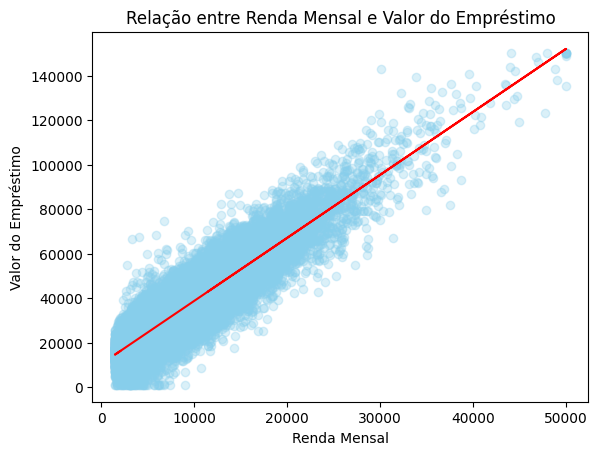

In [24]:
import matplotlib.pyplot as plt
import numpy as np

x = dados['renda_mensal']
y = dados['valor_emprestimo']

# linha de tendência
coeficientes = np.polyfit(x, y, 1)
linha = np.poly1d(coeficientes)

plt.scatter(x, y, color='skyblue', alpha=0.3)
plt.plot(x, linha(x), color='red')

plt.xlabel('Renda Mensal')
plt.ylabel('Valor do Empréstimo')
plt.title('Relação entre Renda Mensal e Valor do Empréstimo')

plt.show()

É possível perceber uma tendência de aumento no valor do empréstimo conforme a renda mensal dos clientes aumenta. A linha de tendência em vermelho mostra esse comportamento geral, indicando que existe uma relação entre essas duas variáveis. Porém, também é possível perceber uma certa dispersão nos pontos, mostrando que outros fatores podem influenciar o valor do empréstimo.

### Relação entre score de crédito e valor do empréstimo

Para analisar outra variável de entrada, será utilizado um gráfico de dispersão entre o score de crédito e o valor do empréstimo.

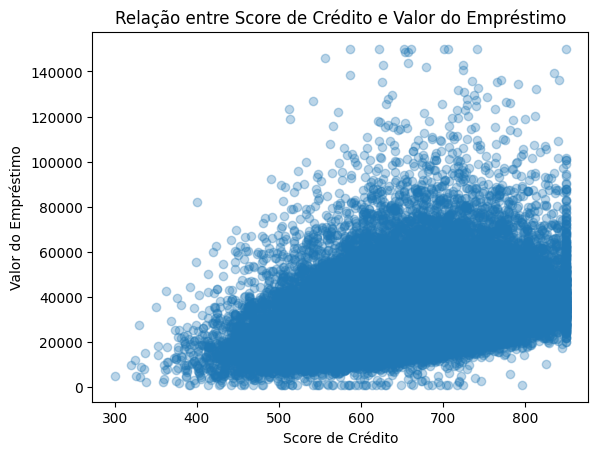

In [25]:
x = dados['score_credito']
y = dados['valor_emprestimo']

plt.scatter(x, y, alpha=0.3)

plt.xlabel('Score de Crédito')
plt.ylabel('Valor do Empréstimo')
plt.title('Relação entre Score de Crédito e Valor do Empréstimo')

plt.show()

É possível observar uma tendência de aumento no valor do empréstimo conforme o score de crédito aumenta. Porém, assim como no gráfico anterior, os pontos apresentam certa dispersão, indicando que o valor do empréstimo também pode depender de outras características do cliente.

## Etapa 4 - Preparar os dados

Os dados serão separados em treinamento e teste. O conjunto de treinamento será utilizado para ensinar o modelo, enquanto o conjunto de teste será utilizado posteriormente para avaliar seu desempenho.

### Separar as variáveis

Primeiro, vamos definir o que é entrada (X) e o que é o resultado que queremos prever (y). X corresponde às características do cliente que o modelo vai usar, e y é o valor do empréstimo que será previsto.

In [26]:
X = dados[['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']]
y = dados['valor_emprestimo']

### Divisão de treinamento e teste

A divisão que será utilizada será de 80% para treinamento e 20% para teste. Essa divisão foi escolhida para manter o equilíbrio, pois iremos dar bastante informação para o modelo aprender, mas também iremos guardar uma quantidade suficiente de dados para os testes.

Para essa divisão, será utilizada a função `train_test_split`, disponível na biblioteca `scikit-learn`. Essa função permite separar os dados em conjuntos de treinamento e teste.

In [27]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

O `test_size=0.2` significa que 20% dos dados serão separados para teste, enquanto os outros 80% serão utilizados para treinamento.

O `random_state=42` faz com que a divisão seja reproduzível, ou seja, ao executar o código novamente, os mesmos dados serão separados para treinamento e teste.

### Proporção

A divisão dos dados resultou em 40.000 registros para treinamento, correspondendo a 80% da base, e 10.000 registros para teste, correspondendo aos 20% restantes.

In [28]:
print("Dados de treinamento:", X_treino.shape[0])
print("Dados de teste:", X_teste.shape[0])

Dados de treinamento: 40000
Dados de teste: 10000


## Etapa 5 - Treinar o modelo

Nesta etapa, será utilizado um algoritmo de regressão linear para criar um modelo capaz de prever o valor do empréstimo com base nas características dos clientes.

### Criar o modelo

Primeiro, será importado o `LinearRegression`, que será utilizado para criar o modelo de regressão.

In [29]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

### Treinar o modelo

Após criar o modelo, ele será treinado utilizando os dados de treinamento. Dessa forma, o modelo poderá aprender a relação entre as características dos clientes e o valor dos empréstimos.

In [30]:
modelo.fit(X_treino, y_treino)

LinearRegression()

O `.fit()` é justamente o comando que faz o modelo aprender com os dados.

### Gerar as previsões

Depois do treinamento, o modelo será utilizado para gerar previsões utilizando os dados que foram separados para teste.

In [31]:
y_pred = modelo.predict(X_teste)

y_pred

array([14806.33565684, 29512.49287915, 25840.73554724, ...,
       37098.02961436, 34521.68648516, 42404.37788797])

`y_pred` vai guardar os valores de empréstimo previstos pelo modelo para os clientes que fazem parte do conjunto de teste.

## Etapa 6 - Avaliar o modelo

O desempenho do modelo será avaliado comparando os valores reais dos empréstimos com os valores previstos pelo modelo. Para isso, serão utilizadas duas métricas de avaliação: MAE e RMSE.

### Métricas de avaliação

- O MAE (Erro Absoluto Médio) representa, em média, o quanto as previsões do modelo se afastam dos valores reais.

- O RMSE (Raiz do Erro Quadrático Médio) também mede o erro das previsões, mas dá um peso maior para erros maiores.

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_teste, y_pred)
rmse = np.sqrt(mean_squared_error(y_teste, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2985.9449770383862
RMSE: 4014.167667409163


O valor do MAE foi de aproximadamente 2.985,94 reais. Isso significa que, em média, as previsões do modelo apresentam uma diferença de cerca de 2.985,94 reais em relação aos valores reais dos empréstimos.

O RMSE foi de aproximadamente 4.014,17 reais. Essa métrica também representa o erro das previsões, mas dá maior peso para erros maiores. Por isso, o valor do RMSE ficou acima do MAE, indicando que algumas previsões apresentaram erros maiores.

## Etapa 7 - Comparar valores reais e previstos

Nesta etapa, serão comparados alguns valores reais dos empréstimos com os valores previstos pelo modelo. Essa comparação permite observar o quanto as previsões se aproximam dos valores que realmente foram registrados na base.

### Comparação entre valores reais e previstos

A tabela abaixo apresenta alguns exemplos dos valores reais e dos valores previstos pelo modelo.

In [33]:
comparacao = pd.DataFrame({
    'Valor real': y_teste.values[:10],
    'Valor previsto': y_pred[:10]
})

comparacao

,Valor real,Valor previsto
0,22268.46,14806.335657
1,27457.59,29512.492879
2,25451.04,25840.735547
3,23890.67,21077.522905
4,27754.95,27919.314046
5,12544.92,14530.910394
6,28759.01,27385.966936
7,46454.49,41011.609092
8,43199.01,36525.087756
9,34051.39,35786.960945


### Análise da comparação

Ao comparar os valores reais com os valores previstos, é possível perceber que as previsões apresentam valores próximos aos valores reais em boa parte dos exemplos. Porém, também existem algumas diferenças entre eles, o que é esperado em um modelo de regressão.

Essas diferenças entre os valores estão relacionadas aos erros apresentados pelas métricas MAE e RMSE na etapa anterior.

## Etapa 8 - Fazer uma previsão

Iremos considerar um novo cliente com características criadas para realizar uma previsão do valor de empréstimo pelo modelo.

### Características do novo cliente

O novo cliente terá as seguintes características:

In [34]:
novo_cliente = pd.DataFrame({
    'idade': [30],
    'renda_mensal': [6000],
    'score_credito': [700],
    'historico_pagamentos': [90]
})

novo_cliente

,idade,renda_mensal,score_credito,historico_pagamentos
0,30,6000,700,90


### Valor previsto

O modelo será utilizado para prever o valor do empréstimo para esse novo cliente.

In [35]:
previsao = modelo.predict(novo_cliente)

print("Valor previsto do empréstimo:", previsao[0])

Valor previsto do empréstimo: 30697.23259790543


### Interpretação do resultado

Para o novo cliente, com 30 anos, renda mensal de 6.000 reais, score de crédito de 700 e histórico de pagamentos de 90, o modelo estimou um valor de empréstimo de aproximadamente 30.697,23 reais.

Esse resultado representa a estimativa gerada pelo modelo com base nas características informadas e nos padrões aprendidos durante o treinamento.

## Etapa 9 - Conclusão

O modelo de regressão apresentou resultados razoáveis para estimar o valor dos empréstimos. As métricas de avaliação mostraram um erro médio de aproximadamente 2.985,94 reais pelo MAE e um RMSE de aproximadamente 4.014,17 reais. Ao comparar os valores reais com os previstos, foi possível perceber que algumas previsões ficaram próximas dos valores reais, enquanto outras apresentaram diferenças maiores.

Dessa forma, o modelo consegue realizar estimativas com base nas características dos clientes, mas as previsões não são exatas e podem apresentar erros.

### Principais limitações

Uma das limitações do modelo está relacionada ao uso da Regressão Linear, pois ela considera relações lineares entre as características dos clientes e o valor do empréstimo. Caso existam relações mais complexas entre essas variáveis, o modelo pode não conseguir representá-las completamente.

Além disso, o modelo aprende a partir dos dados disponíveis na base. Por isso, se novos clientes apresentarem características muito diferentes das observadas durante o treinamento, as previsões podem não apresentar o mesmo comportamento.